In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

files = glob.glob('/home/jorge/Documents/IDX/datasets/*.csv')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df.head()

sns.set_theme(style='whitegrid')

print(df.shape)


(281823, 78)


In [2]:
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

print(f"There are {df.shape[0]} rows and {df.shape[1]} columns after filtering data for Residential and SingleFamilyResidence.")


(141997, 78)
There are 141997 rows and 78 columns after filtering data for Residential and SingleFamilyResidence.


In [3]:
print("ClosePrice Description")
print("\n")

print(df['ClosePrice'].describe())

ClosePrice Description


count    1.419970e+05
mean     1.344654e+06
std      8.084465e+06
min      0.000000e+00
25%      6.250000e+05
50%      8.900000e+05
75%      1.425000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64


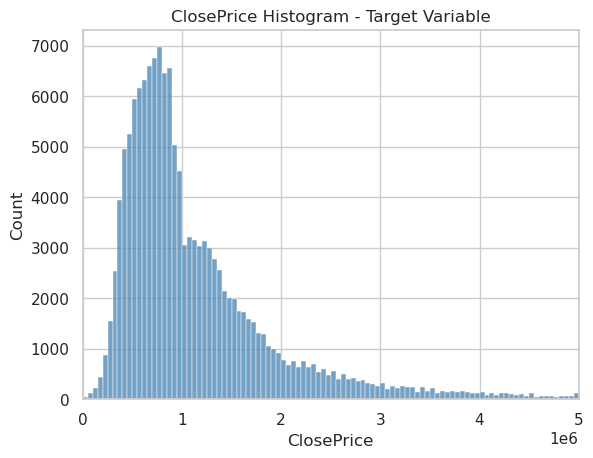

In [4]:
# Chose to limit ClosePrice to 5000000, since anything over is an extreme outlier, as shown by the histogram

filtered_data = df[df['ClosePrice'] <= 5000000]
sns.histplot(filtered_data['ClosePrice'], bins=100, color='steelblue')
plt.xlim(0,5000000)
plt.title("ClosePrice Histogram - Target Variable")
plt.show()

In [5]:
print("LivingArea Description")
print("\n")
print(df['LivingArea'].describe())

LivingArea Description


count    141919.000000
mean       2048.649644
std        1044.085649
min           0.000000
25%        1386.000000
50%        1820.000000
75%        2440.000000
max       56500.000000
Name: LivingArea, dtype: float64


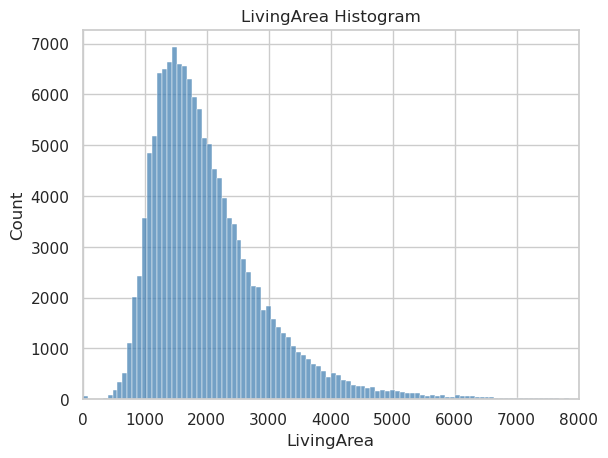

In [6]:
# Chose to limit square footage to 8000, since anything over is an extreme outlier, as shown by the histogram

filtered_data = df[df['LivingArea'] <= 8000]
sns.histplot(filtered_data['LivingArea'], bins=100, color='steelblue')
plt.xlim(0,8000)
plt.title("LivingArea Histogram")
plt.show()

In [7]:
print("BedroomsTotal Description")
print("\n")
print(df['BedroomsTotal'].describe())

BedroomsTotal Description


count    141997.000000
mean          3.492581
std           0.963529
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          22.000000
Name: BedroomsTotal, dtype: float64


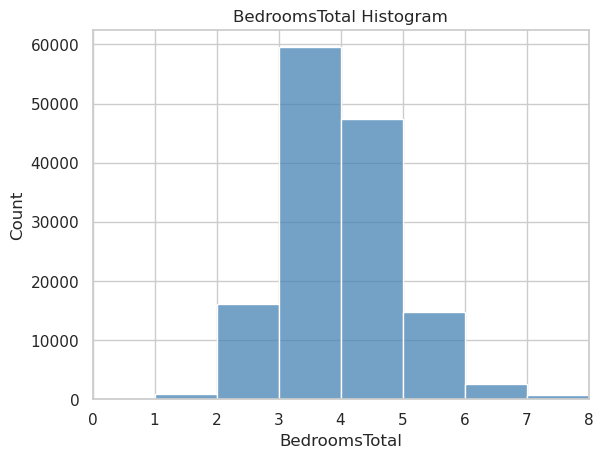

In [8]:
# Chose to limit bedrooms to 10, since anything over is an extreme outlier, as shown by the histogram

filtered_data = df[df['BedroomsTotal'] <= 8]
sns.histplot(filtered_data['BedroomsTotal'], bins=8, color='steelblue')
plt.xlim(0,8)
plt.title("BedroomsTotal Histogram")
plt.show()

In [9]:
print("BathroomsTotalInteger Description")
print("\n")
print(df['BathroomsTotalInteger'].describe())

BathroomsTotalInteger Description


count    141984.000000
mean          2.632452
std           1.131934
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          35.000000
Name: BathroomsTotalInteger, dtype: float64


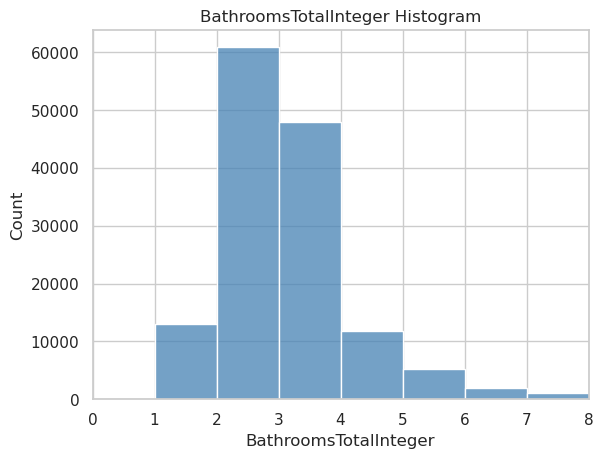

In [10]:
# Chose to limit bathrooms to 10, since anything over is an extreme outlier, as shown by the histogram

filtered_data = df[df['BathroomsTotalInteger'] <= 8]
sns.histplot(filtered_data['BathroomsTotalInteger'], bins=8, color='steelblue')
plt.xlim(0,8)
plt.title("BathroomsTotalInteger Histogram")
plt.show()

In [11]:
print("LotSizeAcres Description")
print("\n")
print(df['LotSizeAcres'].describe())

LotSizeAcres Description


count    139563.000000
mean         14.023840
std         785.055611
min           0.000000
25%           0.130000
50%           0.167400
75%           0.240000
max      127631.000000
Name: LotSizeAcres, dtype: float64


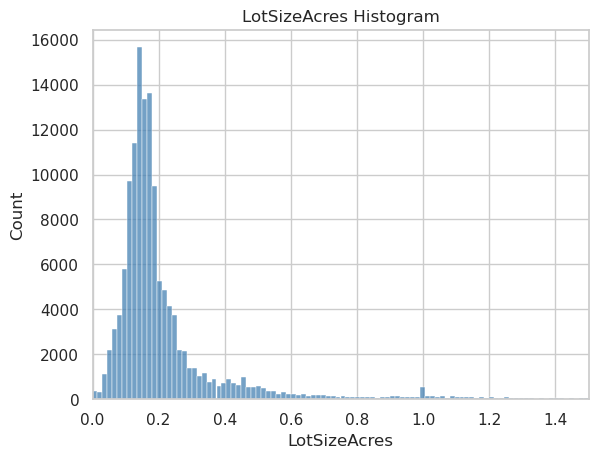

In [12]:
# Chose to limit lot size to 1.5 acres, since anything over is an extreme outlier, as shown by the histogram

filtered_data = df[df['LotSizeAcres'] <= 1.5]
sns.histplot(filtered_data['LotSizeAcres'], bins=100, color='steelblue')
plt.xlim(0,1.5)
plt.title("LotSizeAcres Histogram")
plt.show()

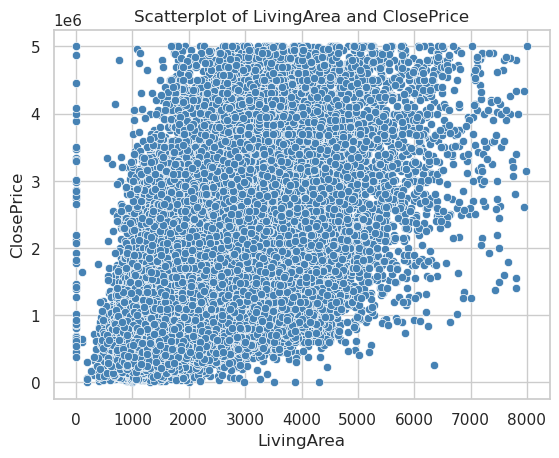

In [13]:
# Through plotting this, it becomes clear there are outliers around x=0. Errors/incomplete data possibly

filtered_data= df[(df['LivingArea'] <= 8000 ) & (df['ClosePrice'] <= 5000000)]
sns.scatterplot(data = filtered_data, x='LivingArea', y='ClosePrice', color='steelblue')
plt.title("Scatterplot of LivingArea and ClosePrice")
plt.show()

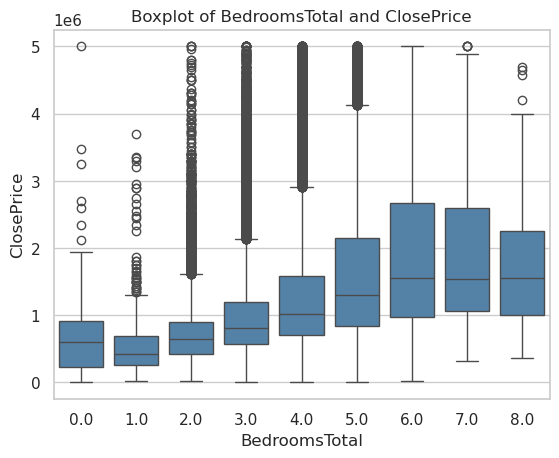

In [14]:
# Many outliers can be seen for 2<x<5. Small rises in ClosePrice, but price plateaus at around 6 bedrooms

filtered_data= df[(df['BedroomsTotal'] <= 8 ) & (df['ClosePrice'] <= 5000000)]
sns.boxplot(data = filtered_data, x='BedroomsTotal', y='ClosePrice', color='steelblue')
plt.title("Boxplot of BedroomsTotal and ClosePrice")
plt.show()

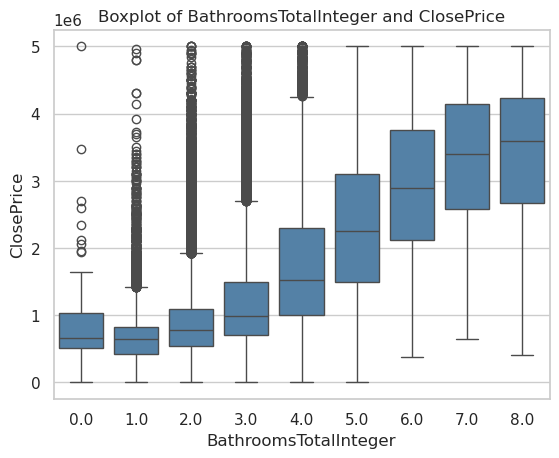

In [15]:
# Many outliers within 1<x<4. Steady rise in median pricing as bathrooms increase

filtered_data= df[(df['BathroomsTotalInteger'] <= 8 ) & (df['ClosePrice'] <= 5000000)]
sns.boxplot(data = filtered_data, x='BathroomsTotalInteger', y='ClosePrice', color='steelblue')
plt.title("Boxplot of BathroomsTotalInteger and ClosePrice")
plt.show()



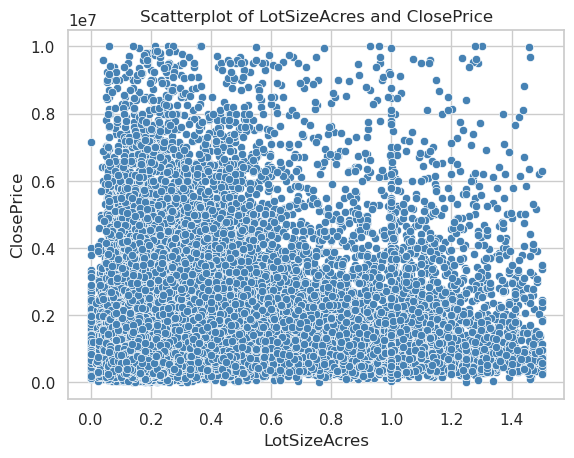

In [16]:
# From scatterplot, does not seem to be any meaningful correlation between lot size and closeprice

filtered_data= df[(df['LotSizeAcres'] <= 1.5 ) & (df['ClosePrice'] <= 10000000)]
sns.scatterplot(data = filtered_data, x='LotSizeAcres', y='ClosePrice', color='steelblue')
plt.title("Scatterplot of LotSizeAcres and ClosePrice")
plt.show()

In [17]:
print("YearBuilt Description")
print("\n")
print(df['YearBuilt'].describe())

YearBuilt Description


count    141900.000000
mean       1975.809669
std          27.606572
min        1776.000000
25%        1956.000000
50%        1976.000000
75%        1998.000000
max        2026.000000
Name: YearBuilt, dtype: float64


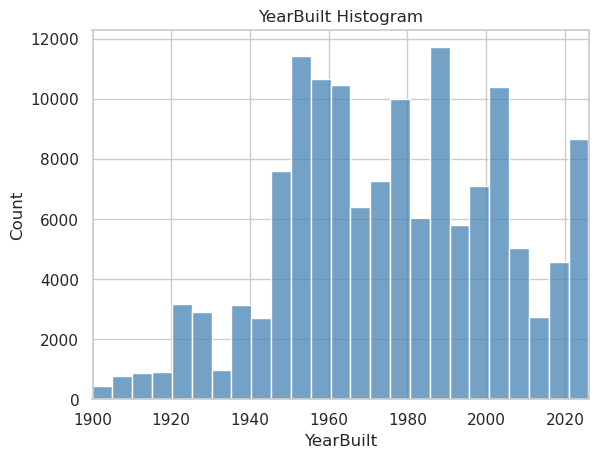

In [18]:
# Chose to limit YearBuilt to after 1900, since anything over is an extreme outlier

filtered_data = df[df['YearBuilt'] >= 1900]
sns.histplot(filtered_data['YearBuilt'], bins=25, color='steelblue')
plt.xlim(1900,2026)
plt.title("YearBuilt Histogram")
plt.show()

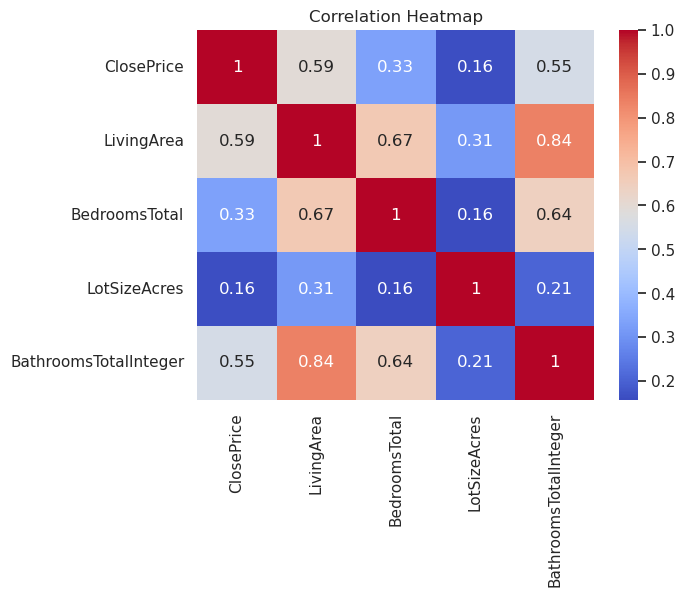

In [19]:
# Heatmap for showing correlation between columns
# ClosePrice seems to be most correlated to LivingArea and BathroomsTotalInteger
# LivingArea and Bathrooms have high correlation as well
# LivingArea and BedroomsTotal also have a high correlation

filtered_data= df[(df['LivingArea'] <= 8000 ) & (df['ClosePrice'] <= 10000000) 
& (df['BedroomsTotal'] <= 8) & (df['BathroomsTotalInteger'] <= 8)
& (df['LotSizeAcres'] <= 1.5)]

columns = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'LotSizeAcres', 'BathroomsTotalInteger']
correlation = filtered_data[columns].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# The Heatmap above is informative, but I want to check correlation between ClosePrice and other features
# In case there are less obvious features that should be considered for the model

# Check all numeric columns correlation

# Note: this is without filtering though, so numbers will differ from the heatmap above
# Outliers are still present, [FIX] so correlations will be lower

numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_corr = df[numeric_cols].corr()['ClosePrice'].sort_values(ascending=False)
print("NUMERIC CORRELATIONS WITH CLOSEPRICE:")
print(numeric_corr)

# Check all categorical columns

print("\nCATEGORICAL PRICE VARIATION:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    try:
        variance = df.groupby(col)['ClosePrice'].median().std()
        nunique = df[col].nunique()
        print(f"{col}: variance={variance:.0f}, unique={nunique}")
    except:
        pass

NUMERIC CORRELATIONS WITH CLOSEPRICE:
ClosePrice                      1.000000
BuildingAreaTotal               0.672071
BelowGradeFinishedArea          0.412195
ListPrice                       0.184926
LivingArea                      0.115918
BathroomsTotalInteger           0.101728
BedroomsTotal                   0.063242
LotSizeArea                     0.056489
OriginalListPrice               0.038110
AssociationFee                  0.034010
Stories                         0.025568
GarageSpaces                    0.009440
DaysOnMarket                    0.008010
ParkingTotal                    0.001160
YearBuilt                       0.000704
ListingKeyNumeric               0.000602
ListingKey                      0.000602
LotSizeAcres                    0.000553
LotSizeSquareFeet               0.000481
Longitude                      -0.006503
StreetNumberNumeric            -0.009810
Latitude                       -0.010169
MainLevelBedrooms              -0.011147
FireplacesTotal    

/tmp/ipykernel_12249/3706027569.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


UnparsedAddress: variance=8128858, unique=140293
PropertyType: variance=nan, unique=1
ListOfficeName: variance=13065370, unique=11375
BuyerOfficeName: variance=1374716, unique=12813
CoListOfficeName: variance=1415512, unique=3303
ListAgentFullName: variance=8520949, unique=45959
CoListAgentFirstName: variance=1698869, unique=4032
CoListAgentLastName: variance=8389444, unique=8205
BuyerAgentMlsId: variance=6145854, unique=63082
BuyerAgentFirstName: variance=7118261, unique=12739
BuyerAgentLastName: variance=1848826, unique=26257
AssociationFeeFrequency: variance=254343, unique=4
MLSAreaMajor: variance=28054593, unique=1028
CountyOrParish: variance=427885, unique=60
MlsStatus: variance=nan, unique=1
ElementarySchool: variance=749634, unique=1260
AttachedGarageYN: variance=8485, unique=2
BuilderName: variance=16118028, unique=1467
PropertySubType: variance=nan, unique=1
SubdivisionName: variance=1387103, unique=8041
BuyerOfficeAOR: variance=431053, unique=59
ListingId: variance=8087410, u

In [21]:
# Seeing how many null values are present in each column
# This will help me determine whether a feature is worth keeping for the model
# Too many nulls means we are losing out on lots of data

pd.set_option('display.max_rows', None)
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
corr = df.select_dtypes(include='number').corr()['ClosePrice']

result = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
result['correlation'] = corr
print(result.sort_values('null_pct', ascending=False))

                              null_count  null_pct  correlation
MiddleOrJuniorSchoolDistrict      141997     100.0          NaN
BusinessType                      141997     100.0          NaN
CoveredSpaces                     141997     100.0          NaN
TaxYear                           141997     100.0          NaN
AboveGradeFinishedArea            141997     100.0          NaN
ElementarySchoolDistrict          141997     100.0          NaN
TaxAnnualAmount                   141997     100.0          NaN
FireplacesTotal                   141997     100.0          NaN
WaterfrontYN                      141924      99.9          NaN
BelowGradeFinishedArea            140977      99.3     0.412195
BasementYN                        138563      97.6          NaN
BuilderName                       135531      95.4          NaN
LotSizeDimensions                 133007      93.7          NaN
BuildingAreaTotal                 132503      93.3     0.672071
CoBuyerAgentFirstName             128727

In [22]:
# As for the criteria that I am using to decide what features should be in the model,
# Refer to the criterion below:

"""" For numerical features you want:

High correlation with ClosePrice, above 0.1 at minimum, ideally above 0.2. Below that it's adding noise more than signal
Low null percentage, above 30% null is risky for model
Low multicollinearity with other features especially for linear regression
Makes intuitive sense, must be explain why a feature would affect price, as correlation can be coincidental

For categorical features you want:

Low unique values, keeps your feature matrix manageable after one-hot encoding
High price variance across categories, means the category actually separates expensive from cheap
Low null percentage, above 30% null is risky for model

These matter because:
Low unique + low variance = clean but useless
High variance + high unique = useful signal but blows up your matrix
Low unique + high variance + 80% null = you'd lose most of your data imputing or dropping

""""

SyntaxError: unterminated string literal (detected at line 22) (1705288629.py, line 22)

In [ ]:
# After Considering These Criterion, The Features I Am Considering to Include in the Model Are:
# 'ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 
#'LotSizeSquareFeet', 'YearBuilt', 'CloseDate', 'Latitude', 'Longitude',
#'City', 'MLSAreaMajor', 'CountyOrParish', 'AssociationFee', 'Stories',
#'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN'